# SALES DATA ANALYSIS:-


# About this Project:-
In this project I explored the sales dataset to understand the factors affecting revenue through visualizations, summary-statistics and feature based analysis.

# Objective:-
To perfrom Exploratory Data Analysis (EDA) on the sales dataset to identify patterns and factors that influenced growth, revenue, customer satisfaction, behaviour etc.

# Key Research Questions:-

1. Which products contribute most and least to revenue?
2. What are the overall gross income and gross margin percentage?
3. Are customer ratings associated with product type, city, payment mode, or sales value?
4. Which branch/city performs best in terms of revenue?

# Importing Relevant libraries and dataset:-

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Sales dataset/SuperMarket Analysis.csv')

# Basic Inspection:-

In [ ]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
data.tail()
# here cogs --> Cost of Goods sold

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


In [ ]:
data.info() # here we dont have any null values but there could be some hidden null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [ ]:
data.describe()
# all the rows have data in them.
# Avg sales is approx 254 and max is 1042 which can be considered as outlier
# Gross margin is same across all the products
# Minimum sales is of 10 and gross income is 0.5.

,Unit price,Quantity,Tax 5%,Sales,Date,COGS,Gross_margin_percent,GrossIncome,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905e+00,15.379369,6.97270
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905e+00,49.650000,10.00000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858


In [ ]:
data.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [ ]:
data.select_dtypes(include = 'float')

,Unit price,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
0,74.69,26.1415,548.9715,522.83,4.761905,26.1415,9.1
1,15.28,3.8200,80.2200,76.40,4.761905,3.8200,9.6
2,46.33,16.2155,340.5255,324.31,4.761905,16.2155,7.4
3,58.22,23.2880,489.0480,465.76,4.761905,23.2880,8.4
4,86.31,30.2085,634.3785,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...
995,40.35,2.0175,42.3675,40.35,4.761905,2.0175,6.2
996,97.38,48.6900,1022.4900,973.80,4.761905,48.6900,4.4
997,31.84,1.5920,33.4320,31.84,4.761905,1.5920,7.7
998,65.82,3.2910,69.1110,65.82,4.761905,3.2910,4.1


In [ ]:
data['Branch'].value_counts()

,count
Branch,
Alex,340
Cairo,332
Giza,328


In [ ]:
data['City'].value_counts()

,count
City,
Yangon,340
Mandalay,332
Naypyitaw,328


In [ ]:
data['Payment'].value_counts()

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


# Finding and Handling Duplicate values:-

In [ ]:
data[data.duplicated()].sum() # there are no duplicate values in the dataset

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0.0
Quantity,0
Tax 5%,0.0
Sales,0.0


# Finding and Handling missing values:-

In [ ]:
data.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


# Feature Engineering :-  
Creating new columns for further analysis, Renaming Columns.

In [ ]:
data.rename(columns = {'Product line':'ProductType'},inplace = True) # renaming column Product line to product type for clarity

# Visualization:-
We have cleaned the data, there were no missing or no duplicate values so now we are going to visualize the data and try to find some insights from this.

# 1. Which products contribute most and least to revenue?

In [ ]:
data.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'ProductType', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [ ]:
# (Unitprice * Quantity) + Tax = Sales (Revenue)
# Sales(Revenue) - COGS(cost of goods sold) = Gross income(Profit)
Revenue_prod = data.groupby(['ProductType'])['Sales'].sum().round(2).reset_index()
Revenue_prod.columns = ['ProductType','Sum']
Revenue_prod

,ProductType,Sum
0,Electronic accessories,54337.53
1,Fashion accessories,54305.90
2,Food and beverages,56144.84
3,Health and beauty,49193.74
4,Home and lifestyle,53861.91
5,Sports and travel,55122.83


In [ ]:
fig_bar = px.bar(Revenue_prod,x='ProductType',y='Sum',color = 'ProductType')

# Using various methods to update the chart
fig_bar.update_layout(
    title = 'Overall Sales(Revenue) across Product types',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold')
)
fig_bar.update_xaxes(
    title = 'Product Type',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)
fig_bar.update_yaxes(
    title = 'Total Sales(Revenue)',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black'),range = [0,80000])
fig_bar.show()

**Chart Selection:-** I chose a bar chart because it effectively compares total sales(revenue) across product types, allowing us to easily identify performance differences between categories.

**Key Findings:-** The bar chart reveals that total sales is nearly equal across all product types, except for a slight decline in Health & Beauty.

**Business Implications:-** This suggests that, despite overall balance, Health & Beauty may be underperforming, possibly due to limited product variety or weaker marketing

**Recommended Actions:-** We recommend a targeted review of Health & Beauty offerings, exploring new product additions, and potentially adjusting marketing strategies to boost this category

In [ ]:
Avg_Revenue_prod = data.groupby(['ProductType'])['Sales'].mean().round(2).reset_index()
Avg_Revenue_prod

,ProductType,Sales
0,Electronic accessories,319.63
1,Fashion accessories,305.09
2,Food and beverages,322.67
3,Health and beauty,323.64
4,Home and lifestyle,336.64
5,Sports and travel,332.07


# 2. What are the overall gross income and gross margin percentage?

In [ ]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,ProductType,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
gross_income_prod = data.groupby(['ProductType'])[['gross income']].sum().reset_index()
gross_income_prod

,ProductType,gross income
0,Electronic accessories,2587.5015
1,Fashion accessories,2585.9950
2,Food and beverages,2673.5640
3,Health and beauty,2342.5590
4,Home and lifestyle,2564.8530
5,Sports and travel,2624.8965


In [ ]:
fig_bar_grossincome = px.bar(gross_income_prod,x='ProductType',y='gross income',color = 'ProductType')

fig_bar_grossincome.update_layout(
    title = 'Total gross income across Product types',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold')
)
fig_bar_grossincome.update_xaxes(
    title = 'Product Type',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)
fig_bar_grossincome.update_yaxes(
    title = 'GrossIncome',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black'),range = [0,3000])
fig_bar_grossincome.show()

**Charts Selection:-**  I chose a bar chart because it effectively compares total gross income across product types, allowing us to easily identify performance differences between categories.

**Key Findings:-** The bar chart reveals that total gross income is nearly equal across all product types, except for a slight decline in Health & Beauty.

**Business Implications:-** This suggests that, despite overall balance, Health & Beauty may be underperforming, possibly due to limited product variety or weaker marketing.

**Recommended Actions:-** We recommend a targeted review of Health & Beauty offerings, exploring new product additions, and potentially adjusting marketing strategies to boost this category

In [ ]:
# Renaming column gross income to GrossIncome
data.rename(columns = {'gross income':'GrossIncome','gross margin percentage':'Gross_margin_percent','cogs':'COGS'},inplace = True)

In [ ]:
# Now to calculate overall gross income margin percentage = (total gross income/total sales)*100
# Preparing the data first calculating sum of Sales and GrossIncome for every type of product.
gross_income_margin_per = data.groupby(['ProductType'])[['Sales','GrossIncome']].sum().reset_index()
gross_income_margin_per

,ProductType,Sales,GrossIncome
0,Electronic accessories,54337.5315,2587.5015
1,Fashion accessories,54305.8950,2585.9950
2,Food and beverages,56144.8440,2673.5640
3,Health and beauty,49193.7390,2342.5590
4,Home and lifestyle,53861.9130,2564.8530
5,Sports and travel,55122.8265,2624.8965


In [ ]:
# Calculating overall gross income margin percentage for every product type.
gross_income_margin_per['Overall_gross_income_margin_per'] = (gross_income_margin_per['GrossIncome']/gross_income_margin_per['Sales'])*100
gross_income_margin_per

,ProductType,Sales,GrossIncome,Overall_gross_income_margin_per
0,Electronic accessories,54337.5315,2587.5015,4.761905
1,Fashion accessories,54305.8950,2585.9950,4.761905
2,Food and beverages,56144.8440,2673.5640,4.761905
3,Health and beauty,49193.7390,2342.5590,4.761905
4,Home and lifestyle,53861.9130,2564.8530,4.761905
5,Sports and travel,55122.8265,2624.8965,4.761905


In [ ]:
fig_grossincome_percentage = px.bar(gross_income_margin_per,x='ProductType',y='Overall_gross_income_margin_per',color = 'ProductType')

fig_grossincome_percentage.update_layout(
    title = 'Total gross income margin percentage across Product types',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold')
)
fig_grossincome_percentage.update_xaxes(
    title = 'Product Type',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)
fig_grossincome_percentage.update_yaxes(
    title = 'GrossIncome Percentage',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black'),range = [0,6])
fig_grossincome_percentage.show()

**Chart Selection:-** I chose a bar chart because it effectively compares total gross income across product types, allowing us to easily identify performance differences between categories.

**Key Findings:-** Gross income margin percentage is consistent across all product categories, showing that no product type significantly outperforms or underperforms others in terms of profitability percentage

**Business Implications:-** The lack of variation in gross margin percentage suggests that the business follows a uniform pricing and profit strategy. As a result, increasing profitability may depend more on improving sales performance, demand, and customer purchases rather than changing focus to a specific product category.

**Recommended Actions:-** Focus on increasing sales volume of high-demand products since margin percentage is similar across categories. Prioritizing products with stronger sales can improve overall profitability.

# 3. Are customer ratings associated with product type, city, payment mode, or sales value?

In [ ]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,ProductType,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,COGS,Gross_margin_percent,GrossIncome,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
# Creating another columns to categorize the ratings
def ratings_categorize(ratings):
  if ratings >= 9:
    return 'Excellent'
  elif ratings >= 7 and ratings < 9:
    return 'Good'
  elif ratings >= 5 and ratings < 7:
    return 'Average'
  else:
    return 'Poor'
# applying the defined function operation in Rating column
data['Ratings_categories'] = data['Rating'].apply(ratings_categorize)
ratings_count = data['Ratings_categories'].value_counts().reset_index()
ratings_count

,Ratings_categories,count
0,Average,346
1,Good,335
2,Excellent,166
3,Poor,153


In [ ]:
fig_ratings_cat = px.bar(ratings_count,x='Ratings_categories',y = 'count',color = 'Ratings_categories')

fig_ratings_cat.update_layout(
    title = 'Countplot for Ratings Category',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold'),
    legend=dict(
        x=0.9,
        y=1
    )
)
fig_ratings_cat.update_xaxes(
    title = 'Ratings',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_ratings_cat.update_yaxes(
    title = 'Count',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)
fig_ratings_cat.show()

**Chart Selection:-** I choose a count plot to display the frequency distribution of customer rating categories because it effectively compares the number of observations across categorical groups and highlights overall customer satisfaction patterns.

**Key Findings:-** Customer ratings are concentrated in the Average and Good categories, with comparatively fewer Excellent and Poor ratings. The slightly higher number of Excellent ratings than Poor ratings suggests an overall positive but moderate customer experience.

**Business Implications:-** Customer satisfaction appears stable but not exceptional. Business growth may benefit from improving service quality, customer experience, and product consistency to gradually shift customers from Average to Good and from Good to Excellent satisfaction levels.

**Recommended Actions:-** Investigate the factors influencing lower customer satisfaction by analyzing variables such as product category, purchase experience, branch performance, or payment behavior. Focus on improving the experience of Average-rated customers to increase Good ratings, while identifying opportunities to convert Good experiences into Excellent ones through service and quality improvements.

In [ ]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,ProductType,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,COGS,Gross_margin_percent,GrossIncome,Rating,Ratings_categories
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,Excellent
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,Excellent
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,Good
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,Good
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,Average


In [ ]:
# Ratings across cities and branches to find where we need to work more
ratings_across_cities = data[['City','Ratings_categories']].value_counts().reset_index()
ratings_across_cities

,City,Ratings_categories,count
0,Mandalay,Average,122
1,Yangon,Good,117
2,Naypyitaw,Average,115
3,Naypyitaw,Good,111
4,Yangon,Average,109
5,Mandalay,Good,107
6,Yangon,Excellent,62
7,Naypyitaw,Excellent,60
8,Mandalay,Poor,59
9,Yangon,Poor,52


In [ ]:
data[['City','Branch']].value_counts() # Each city have one branch each so I am using cities for citywise insights.

,,count
City,Branch,
Yangon,Alex,340
Mandalay,Cairo,332
Naypyitaw,Giza,328


In [ ]:
fig_city_ratings = px.bar(
    ratings_across_cities,
    x='City',
    y='count',
    color='Ratings_categories',   # acts like hue
    barmode='group'            # side by side bars
)
fig_city_ratings.update_layout(
    title = 'Customer Ratings across cities',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold'),
    legend=dict(
        x=0.9,
        y=1
    )
)
fig_city_ratings.update_xaxes(
    title = 'City',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_city_ratings.update_yaxes(
    title = 'Count',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_city_ratings.show()

**Chart Selection:-** I choose countplot to compare the distribution of customer rating categories across cities because both variables are categorical in nature. This visualization effectively highlights differences in customer satisfaction patterns and allows for easy comparison of rating frequencies between branches/cities.

**Key Findings:-** Customer satisfaction patterns vary across cities. Mandalay shows comparatively weaker customer rating distribution, with fewer Excellent ratings and a higher concentration of Average ratings relative to Good ratings, suggesting lower overall customer satisfaction. Yangon demonstrates moderate performance with stronger Good ratings but still contains a noticeable number of Poor ratings, indicating areas for improvement. In contrast, Naypyitaw displays the strongest customer satisfaction pattern, with higher Good and Excellent ratings and comparatively fewer Poor ratings.

**Business Implications:-** Differences in customer rating distribution across cities suggest inconsistent customer experience between branches. Mandalay may require greater operational attention to improve customer satisfaction, while Yangon may benefit from targeted service improvements to reduce dissatisfaction. Naypyitaw’s stronger performance may provide useful operational practices or service strategies that could be replicated in lower-performing locations.

**Recommended Actions:-** Conduct deeper analysis to identify the drivers of customer satisfaction differences across cities by evaluating factors such as product availability, staff performance, service quality, payment methods, peak shopping times, and product categories. Prioritize improving Mandalay’s customer experience by converting Average ratings into Good ratings and reducing Poor ratings through targeted operational improvements. Additionally, review Naypyitaw’s stronger practices and explore whether they can be implemented in other branches.


In [ ]:
product_ratings = data[['Ratings_categories','ProductType']].value_counts().reset_index()

In [ ]:
fig_ratings_prod = px.bar(
    product_ratings,
    x='ProductType',
    y='count',
    color='Ratings_categories',   # acts like hue
    barmode='group'            # side by side bars
)
fig_ratings_prod.update_layout(
    title = 'Customer Ratings across different Products',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold'),
    legend=dict(
        x=1.0,
        y=1
    )
)
fig_ratings_prod.update_xaxes(
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_ratings_prod.update_yaxes(
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_ratings_prod.show()

**Chart Selection:-** I choose countplot to compare customer rating distributions across product types, as it effectively represents the frequency of categorical observations and highlights differences in customer satisfaction patterns between product categories.

**Key Findings:-**

 **Food & Beverages** shows the strongest customer satisfaction with higher Good ratings and low Poor ratings.

**Home & Lifestyle** shows relatively higher Poor ratings indicating dissatisfaction.

**Sports & Travel** and other categories show moderate satisfaction with dominance of Average ratings

**Business Implications:-**

Customer satisfaction is inconsistent across product types, indicating category-wise experience differences.

Some categories may not be meeting customer expectations, leading to higher Average or Poor ratings.

Strong categories can be used as benchmarks for improvement.

**Recommended Actions:-**

Analyze successful product categories (Food & Beverages, Fashion Accessories) to identify best practices.

Improve **Sports & Travel** by addressing factors leading to Average ratings.

Investigate **Home & Lifestyle** to identify causes of higher dissatisfaction and reduce Poor ratings.


In [ ]:
# checking if there is any difference in the avg sales acorss customer types further taking ratings categories
data.groupby(['Ratings_categories','Customer type'])['Sales'].mean().reset_index()

,Ratings_categories,Customer type,Sales
0,Average,Member,333.362667
1,Average,Normal,294.944398
2,Excellent,Member,329.139961
3,Excellent,Normal,305.800364
4,Good,Member,329.701484
5,Good,Normal,305.039365
6,Poor,Member,358.570625
7,Poor,Normal,341.989789


In [ ]:
fig_ratings_sales = px.box(data,x='Ratings_categories',y='Sales',color = 'Customer type')
fig_ratings_sales.update_layout(
    title = 'Average revenue by Customer Ratings across customer type',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold'),
    legend=dict(
        x=1.0,
        y=1
    )
)
fig_ratings_sales.update_xaxes(
    title = 'Customer Ratings',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_ratings_sales.update_yaxes(
    title = 'Average Revenue',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black'))
fig_ratings_sales.show()

**Chart Selection:-** I choose box plot to compare revenue distribution across customer ratings and customer types, as it effectively highlights variation, spread, and outliers in spending behavior.

**Key Findings:-**

1.  Revenue is consistent across customer ratings and types, showing no major segmentation-based differences in spending.
2. Customer ratings are centered around Average and Good, with very few Excellent or Poor ratings.
3. Higher spending does not strongly correlate with higher customer satisfaction.

**Business Implications:-**

1. The business has a stable but undifferentiated customer base, where most segments contribute similarly to revenue.
2. Overall experience is “satisfactory but not exceptional”, limiting strong brand loyalty or advocacy.
3. There is a missed opportunity in converting high-value or satisfied customers into loyal promoters.

**Recommended Actions:-**
1. Focus on improving customer experience quality to increase “Excellent” ratings.
2. Use behavior-based segmentation to identify and target high-potential loyal customers.
3. Strengthen personalization and post-purchase engagement to improve satisfaction among high spenders.

# 4. Which branch/city performs best in terms of revenue?

In [ ]:
# Preparing the data to find avg sales across cities and further dividing it into customer type to find additonal insights.
avg_city_revenue = data.groupby(['City','Customer type'])['Sales'].mean().reset_index()
avg_city_revenue

,City,Customer type,Sales
0,Mandalay,Member,330.520276
1,Mandalay,Normal,307.109285
2,Naypyitaw,Member,345.231015
3,Naypyitaw,Normal,325.327534
4,Yangon,Member,331.030405
5,Yangon,Normal,288.697290


In [ ]:
fig_city_revenue = px.bar(avg_city_revenue,
    x='City',
    y='Sales',
    color='Customer type',
    barmode='group')
fig_city_revenue.update_layout(
    title = 'Average sales across Branches',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold'),
    legend=dict(
        x=1.0,
        y=1
    )
)
fig_city_revenue.update_xaxes(
    title = 'City',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_city_revenue.update_yaxes(
    title = 'Average Sales(Revenue)',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black'))
fig_city_revenue.show()

**Chart Selection:-** I choose a bar chart to compare average sales across cities and customer types (Member vs Normal) as it effectively highlights differences in average performance between categorical groups and allows easy comparison of spending behavior across customer segments.

**Key Findings:-**

1. Member customers consistently show higher average sales than normal customers across all cities.

2. The spending gap between members and normal customers is present in all cities but is more noticeable in Yangon.

3. Mandalay and Naypyitaw show only a slight difference between member and normal customer spending.

4. Normal customers maintain a stable but lower average purchase value compared to members.

5. Overall, membership customers demonstrate stronger purchasing behavior across all locations.

**Business Implications:-**
1. The results suggest that the membership program is effective in increasing customer spending and engagement, as members consistently generate higher average sales. This indicates stronger customer loyalty and value among members.

2. At the same time, the presence of a large normal customer base with moderate spending highlights a significant opportunity for revenue growth through customer conversion. Improving engagement with normal customers could directly increase overall sales performance.

**Recommended Actions:-**
1. Develop targeted strategies to convert normal customers into members through loyalty programs, discounts, exclusive offers, and reward-based incentives.

2. Analyze what drives higher spending among members and replicate these factors in customer engagement strategies for non-members.

3. Additionally, evaluate why Yangon shows a stronger membership effect compared to other cities to identify location-specific best practices that can be scaled across all branches.

In [ ]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,ProductType,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,COGS,Gross_margin_percent,GrossIncome,Rating,Ratings_categories
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,Excellent
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,Excellent
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,Good
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,Good
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,Average


In [ ]:
# Converting date column into datetime format.
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
data['Date'].head()

,Date
0,2019-01-05
1,2019-03-08
2,2019-03-03
3,2019-01-27
4,2019-02-08


In [ ]:
data['Month names'] = data['Date'].dt.month_name() # creating another column to store month names bcoz year is same
data.head()

,Invoice ID,Branch,City,Customer type,Gender,ProductType,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,COGS,Gross_margin_percent,GrossIncome,Rating,Ratings_categories,Month names
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,Excellent,January
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,Excellent,March
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,Good,March
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,Good,January
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,Average,February


In [ ]:
# preparing the data to find avg monthly sales across the cities.
avg_monthly_sales = data.groupby(['City','Month names'])['Sales'].mean().reset_index()
avg_monthly_sales

,City,Month names,Sales
0,Mandalay,February,315.819000
1,Mandalay,January,334.919446
2,Mandalay,March,308.904844
3,Naypyitaw,February,329.349825
4,Naypyitaw,January,331.431811
5,Naypyitaw,March,350.934368
6,Yangon,February,317.660856
7,Yangon,January,325.051500
8,Yangon,March,296.528516


In [ ]:
fig_month_sales = px.bar(avg_monthly_sales,
    x='Month names',
    y='Sales',
    color='City',
    barmode='group')
fig_month_sales.update_layout(
    title = 'Average Monthly sales across Cities',
    template = 'plotly_white',
    title_x = 0.5,
    title_font = dict(size = 16,color = 'black',weight = 'bold'),
    legend=dict(
        x=1.0,
        y=1
    )
)
fig_month_sales.update_xaxes(
    title = 'Month names',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black')
)

fig_month_sales.update_yaxes(
    title = 'Average Sales(Revenue)',
    title_font=dict(size=16, color='black'),
    tickfont=dict(size=14, color='black'))
fig_month_sales.show()

**Chart Selection:-** I choose bar chart to compare average monthly sales across cities (January–March) as it effectively highlights differences in average performance between categorical groups over a short time period. This visualization makes it easy to compare city-wise sales trends and identify variations in performance across locations.

**Key Findings:-**
1. In January and February, average monthly sales are relatively consistent across all three cities, indicating similar performance across branches.
2. In March, a noticeable increase in average sales is observed in Naypyitaw, making it the strongest-performing city for that month.
3. Mandalay shows slightly better performance than Yangon in March, though the difference is not significant.
4. Overall, city-wise sales remain stable in the first two months, with a clear uplift in March for specific locations, especially Naypyitaw.

**Business Implications:-**
1. The sharp increase in Naypyitaw’s sales in March suggests the presence of location-specific or time-specific factors influencing customer demand.
2. This variation indicates that external drivers such as promotions, events, or operational changes may significantly impact monthly performance.
3. Understanding these drivers can help identify what contributes to higher sales performance in specific periods or locations.

**Recommended Actions:-**
1. Investigate the factors behind the March sales increase in Naypyitaw, including marketing campaigns, local events, pricing changes, or operational improvements.
2. Analyze whether any specific strategy or initiative was implemented in March that contributed to improved performance.
3. If positive drivers are identified, replicate these strategies across other cities to improve overall sales performance.

In [ ]:
data.head()

,Invoice ID,Branch,City,Customer type,Gender,ProductType,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,COGS,Gross_margin_percent,GrossIncome,Rating,Ratings_categories,Month names
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,Excellent,January
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,Excellent,March
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,Good,March
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,Good,January
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,Average,February


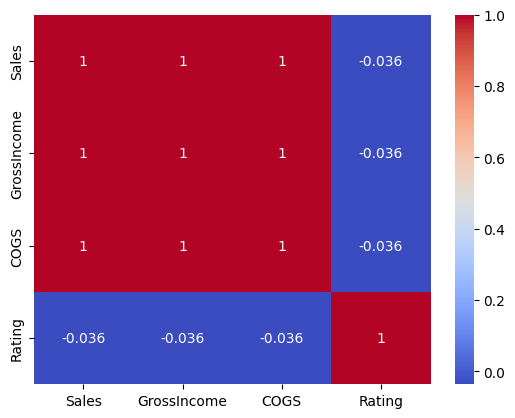

In [ ]:
# Heatmap for continous columns to find correlation if any
fig_relation_data = sns.heatmap(data[['Sales','GrossIncome','COGS','Rating']].corr(),annot = True,cmap = 'coolwarm')
plt.show()

**Chart Selection:-**
I choose a correlation heatmap to analyze relationships between continuous financial variables such as Sales, COGS, and Gross Income.

**Key Findings :-**
1. Sales, COGS, and Gross Income show perfect positive correlation (≈1), indicating they are mathematically dependent.
2. Gross Income is directly derived from Sales and COGS, not an independent metric.
3. Ratings also show a weaker relation with other variables like Sales, COGS etc which indicate they are independent from each other.

**Business Implications:-**
1. The business operates with a fixed pricing or margin structure, meaning profitability is standardized across products.
2. Financial metrics (Sales, COGS, Gross Income) are not independent drivers, reducing variability in profit behavior.

**Recommended Actions:-**
1. Re-evaluate pricing strategy to introduce differentiated margins across product categories if higher profitability segmentation is desired.
2. Analyze whether a flat margin structure is intentional or limiting growth potential.
3. Shift focus toward volume-based or product mix optimization strategies, since profit per unit is not varying.
4. Introduce additional financial KPIs (e.g., contribution margin, discounts impact, net profit) for deeper insight beyond basic derived metrics.

In [ ]:
data[['Sales','COGS','GrossIncome']].describe()

,Sales,COGS,GrossIncome
count,1000.000000,1000.00000,1000.000000
mean,322.966749,307.58738,15.379369
std,245.885335,234.17651,11.708825
min,10.678500,10.17000,0.508500
25%,124.422375,118.49750,5.924875
50%,253.848000,241.76000,12.088000
75%,471.350250,448.90500,22.445250
max,1042.650000,993.00000,49.650000


# Final Conclusions of the project:-



1.**Overall Business Insights:-** The analysis shows that the business operates in a highly stable but low-differentiation environment, where most key metrics such as revenue, ratings, and product performance remain fairly consistent across segments. There are no strong drivers that significantly separate high-performing and low-performing groups.

2.**Key Analytical Conclusions**:-

Customer ratings are not strongly influenced by spending behavior or customer type, as high-spending customers also give average or poor ratings.

Revenue distribution is consistent across branches, product lines, and customer types, with no major outperforming segment.

Product categories show only minor differences in performance, indicating no dominant or underperforming category at a structural level.

Gross margin is uniform across all products, showing a fixed profitability structure rather than variable pricing or cost strategy.

3.**Business Implications:-**

The business is operationally stable but lacks strong growth levers from pricing, segmentation, or customer experience differentiation.

Uniform gross margin suggests limited pricing flexibility or aggressive standardization strategy, which may restrict profit optimization.

Customer satisfaction is decoupled from revenue, indicating missed opportunities in loyalty building and experience optimization.

Product and branch performance consistency suggests growth is not coming from product superiority but from overall demand volume.

# Limitations in Dataset:-



1. The dataset covers only a three-month period, limiting long-term trend, seasonality, and yearly performance analysis.
2. The analysis is based on data from three available branches, which may limit the generalizability of findings across broader business operations.
3. The dataset contains limited business variables, restricting deeper investigation into customer behavior, satisfaction drivers, and root causes behind business performance.